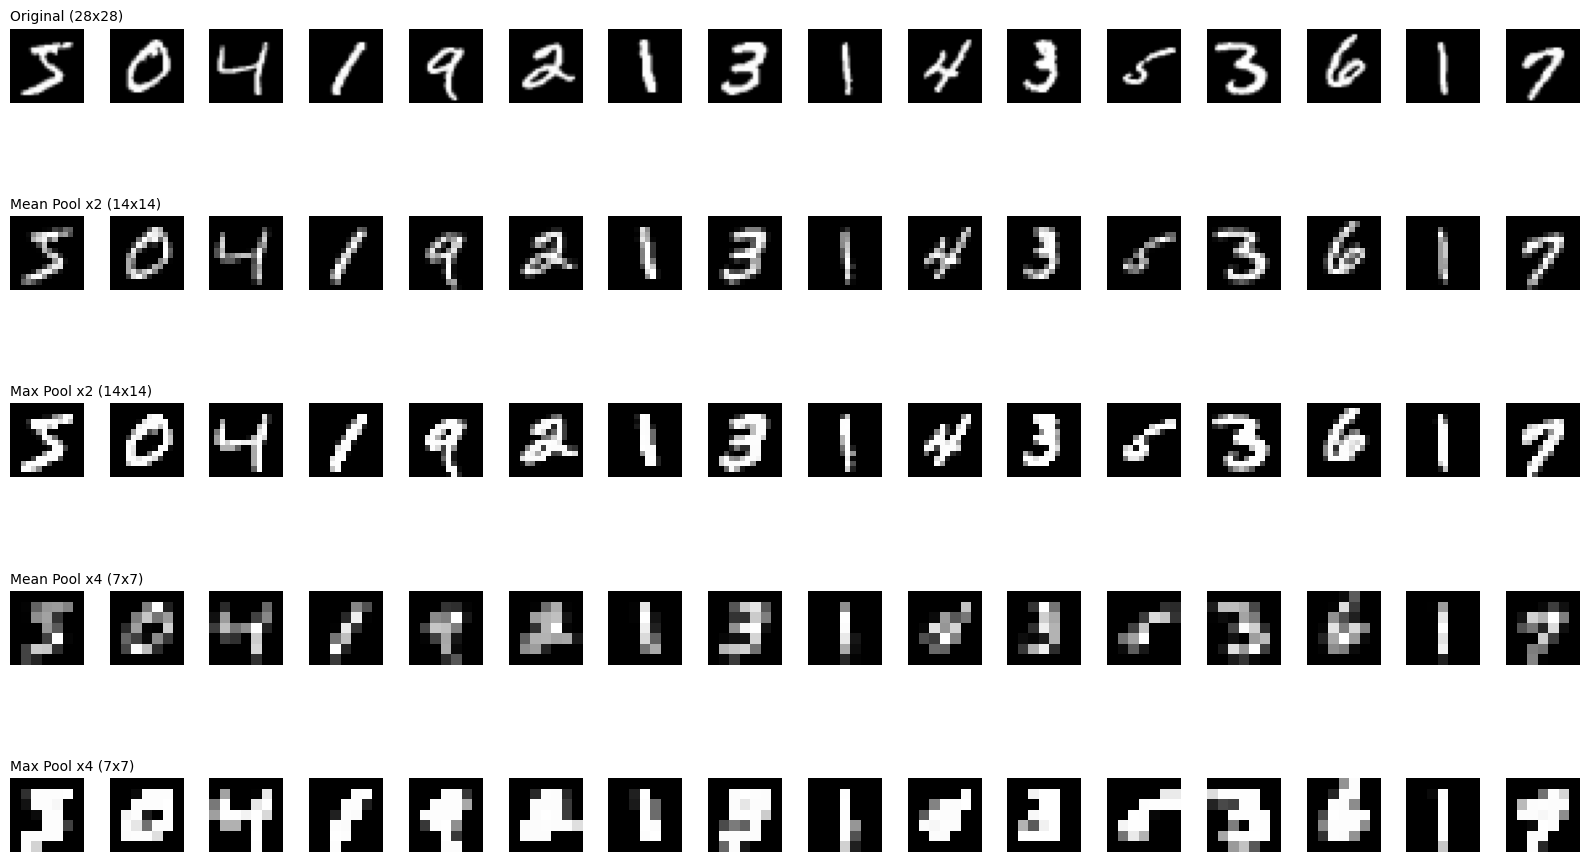

In [ ]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Load MNIST (first 16 images for demo)
transform = transforms.Compose([transforms.ToTensor()])
mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
images = torch.stack([mnist[i][0] for i in range(16)])  # shape: [16, 1, 28, 28]

# Downsampling function
def downsample(images, scale, mode='mean'):
    k = scale
    if mode == 'mean':
        return F.avg_pool2d(images, kernel_size=k)
    elif mode == 'max':
        return F.max_pool2d(images, kernel_size=k)
    else:
        raise ValueError("Mode must be 'mean' or 'max'")

# Visualize original and downsampled
def visualize(images_list, titles):
    n = len(images_list)
    fig, axes = plt.subplots(len(images_list), 16, figsize=(16, 2 * n))
    for i, (imgs, title) in enumerate(zip(images_list, titles)):
        for j in range(16):
            ax = axes[i, j]
            ax.imshow(imgs[j][0], cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(title, fontsize=10, loc='left')
    plt.tight_layout()
    plt.show()

# Generate downsampled versions
down_2_mean = downsample(images, 2, mode='mean')
down_2_max = downsample(images, 2, mode='max')
down_4_mean = downsample(images, 4, mode='mean')
down_4_max = downsample(images, 4, mode='max')

# Show everything
visualize(
    [images, down_2_mean, down_2_max, down_4_mean, down_4_max],
    ['Original (28x28)', 'Mean Pool x2 (14x14)', 'Max Pool x2 (14x14)',
     'Mean Pool x4 (7x7)', 'Max Pool x4 (7x7)']
)
